## Exact Gaussian Beam Formula (Theory)

From classical Gaussian beam optics (Siegman's *Lasers*, Born & Wolf), a beam with waist $w_0$ at $z = z_0$ propagates as:

$$
w(z) = w_0 \sqrt{1 + \left(\frac{z - z_0}{z_R}\right)^2}
$$

where the Rayleigh range is:

$$
z_R = \frac{\pi w_0^2}{\lambda}
$$

This formula is the exact solution to the paraxial wave equation in vacuum for a Gaussian beam. It describes:

- Minimum width $w_0$ at the waist ($z = z_0$)
- Monotonic spreading away from waist
- Asymptotic linear growth: $w(z) \approx \frac{\lambda}{\pi w_0}|z - z_0|$ for $|z - z_0| \gg z_R$


GAUSSIAN BEAM PROPAGATION: VSL vs. Exact Formula

Theory: Exact vacuum Gaussian beam formula
  w(z) = w₀ √[1 + ((z-z₀)/z_R)²]
  where z_R = π w₀²/λ (Rayleigh range)

Source: Siegman, 'Lasers' (1986), Ch. 17

Scenario A) Vacuum (Exact Comparison)
Target waist: 20.0 mm at z = 4000 m

Numerical Results:
  Waist location (X): 4407 m
  Waist location (Y): 4407 m
  Waist width (X):    19.99 mm
  Waist width (Y):    19.99 mm
  F_x at waist:       +1.061e-06
  F_y at waist:       +1.061e-06

Vacuum Verification:
  Waist location error: 10.18%
  Waist width error:    0.03%
  RMS width error:      2.713 mm

End state statistics (z = 5000 m):
  Tilt Tx: +0.00e+00 ± 0.00e+00
  Tilt Ty: +0.00e+00 ± 0.00e+00
  Position X: +0.00e+00 ± 0.00e+00 m
  Position Y: +0.00e+00 ± 0.00e+00 m


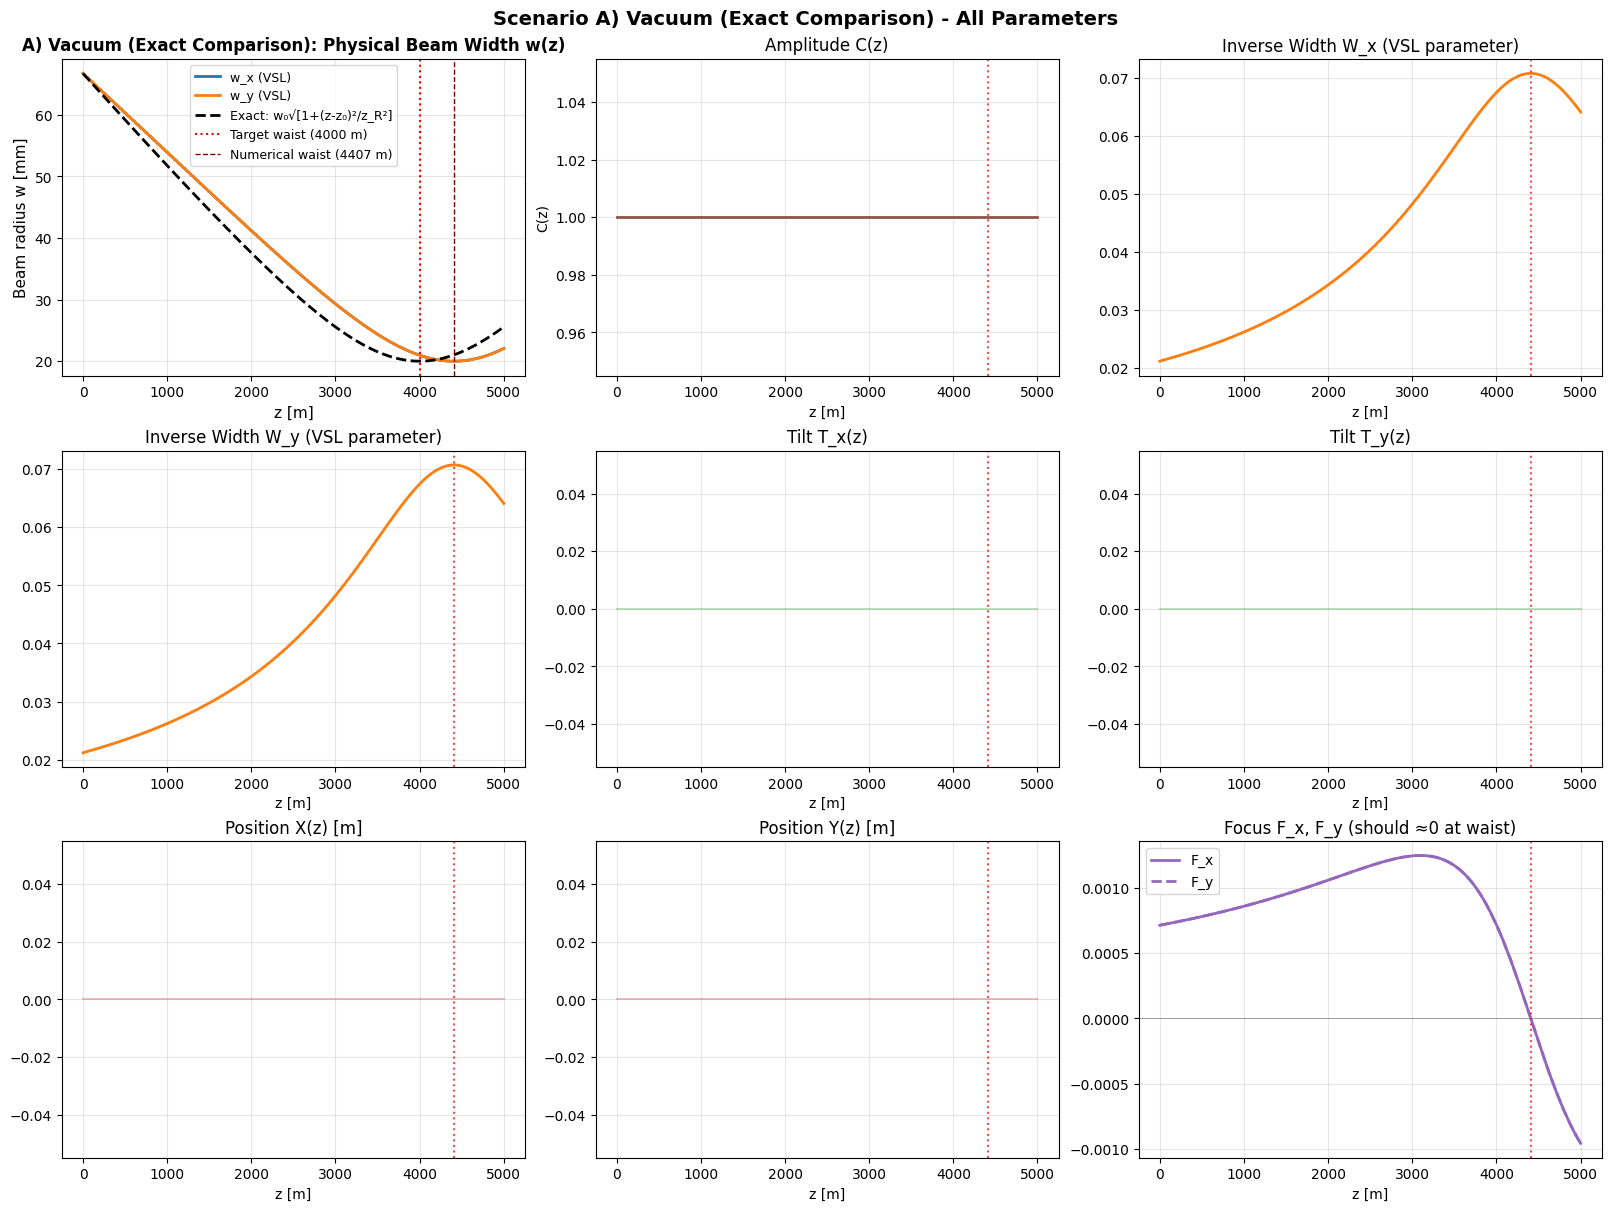


Scenario B) Atmospheric Turbulence
Target waist: 20.0 mm at z = 4000 m

Numerical Results:
  Waist location (X): 4407 m
  Waist location (Y): 4407 m
  Waist width (X):    19.99 mm
  Waist width (Y):    19.99 mm
  F_x at waist:       +1.062e-06
  F_y at waist:       +1.062e-06

End state statistics (z = 5000 m):
  Tilt Tx: +3.99e-10 ± 3.79e-09
  Tilt Ty: -2.02e-10 ± 3.10e-09
  Position X: +3.33e-11 ± 1.44e-10 m
  Position Y: -3.14e-12 ± 1.18e-10 m


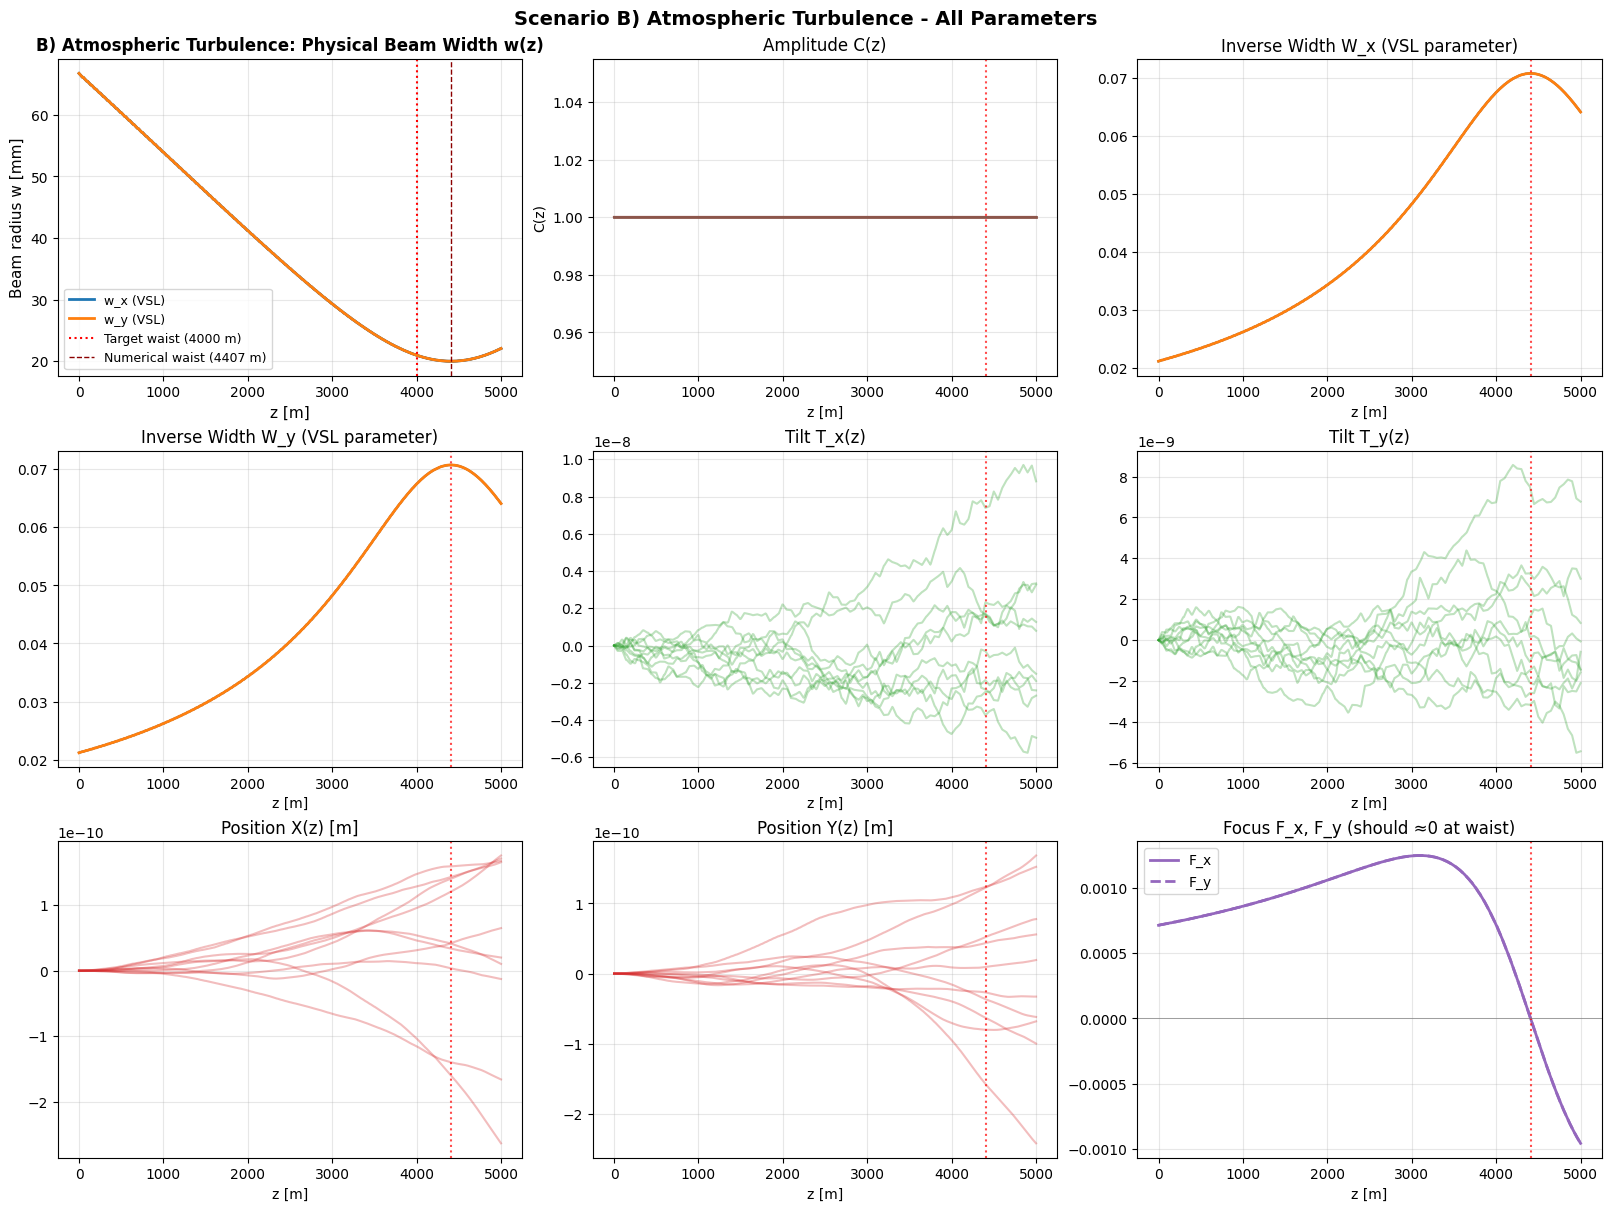

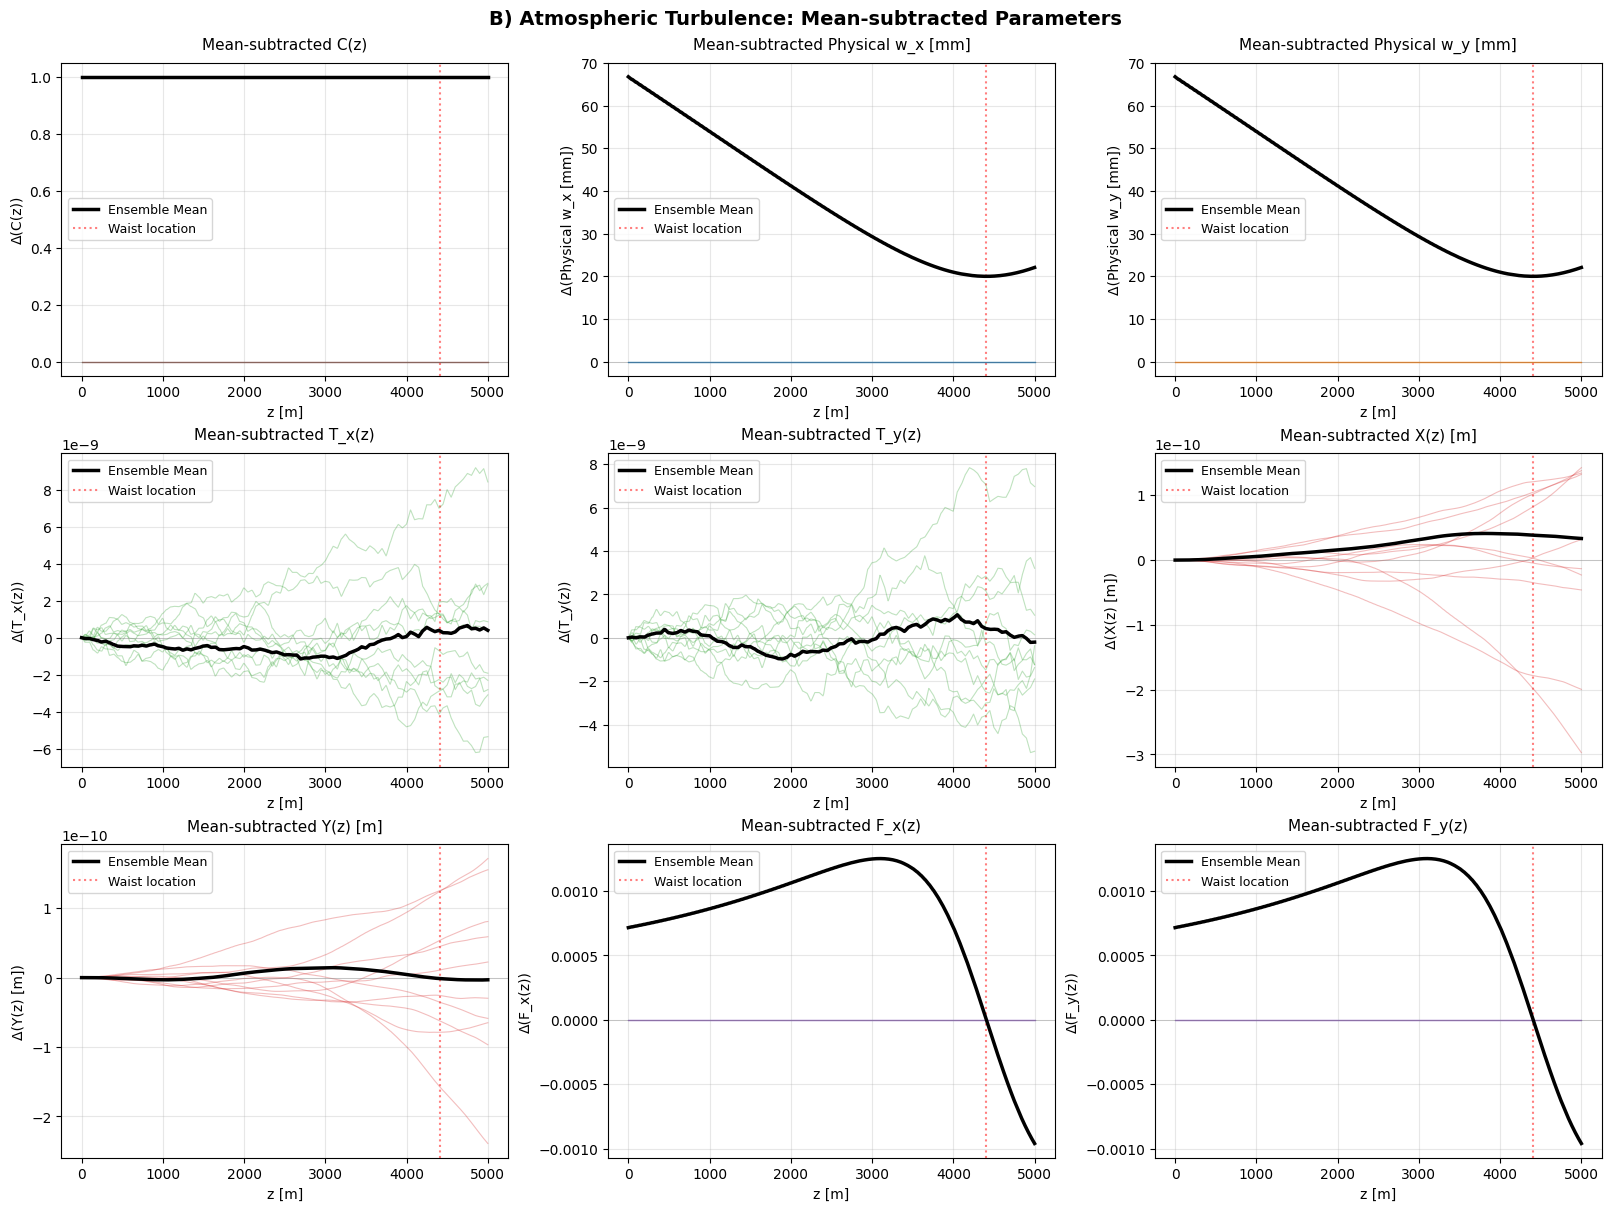


Scenario C) Thermal Blooming
Target waist: 20.0 mm at z = 4000 m

Numerical Results:
  Waist location (X): 4341 m
  Waist location (Y): 4341 m
  Waist width (X):    21.77 mm
  Waist width (Y):    21.77 mm
  F_x at waist:       +6.934e-06
  F_y at waist:       +6.934e-06

End state statistics (z = 5000 m):
  Tilt Tx: +1.07e-16 ± 7.58e-17
  Tilt Ty: -1.26e-17 ± 5.05e-18
  Position X: -4.62e-18 ± 3.63e-18 m
  Position Y: +4.98e-19 ± 3.04e-19 m


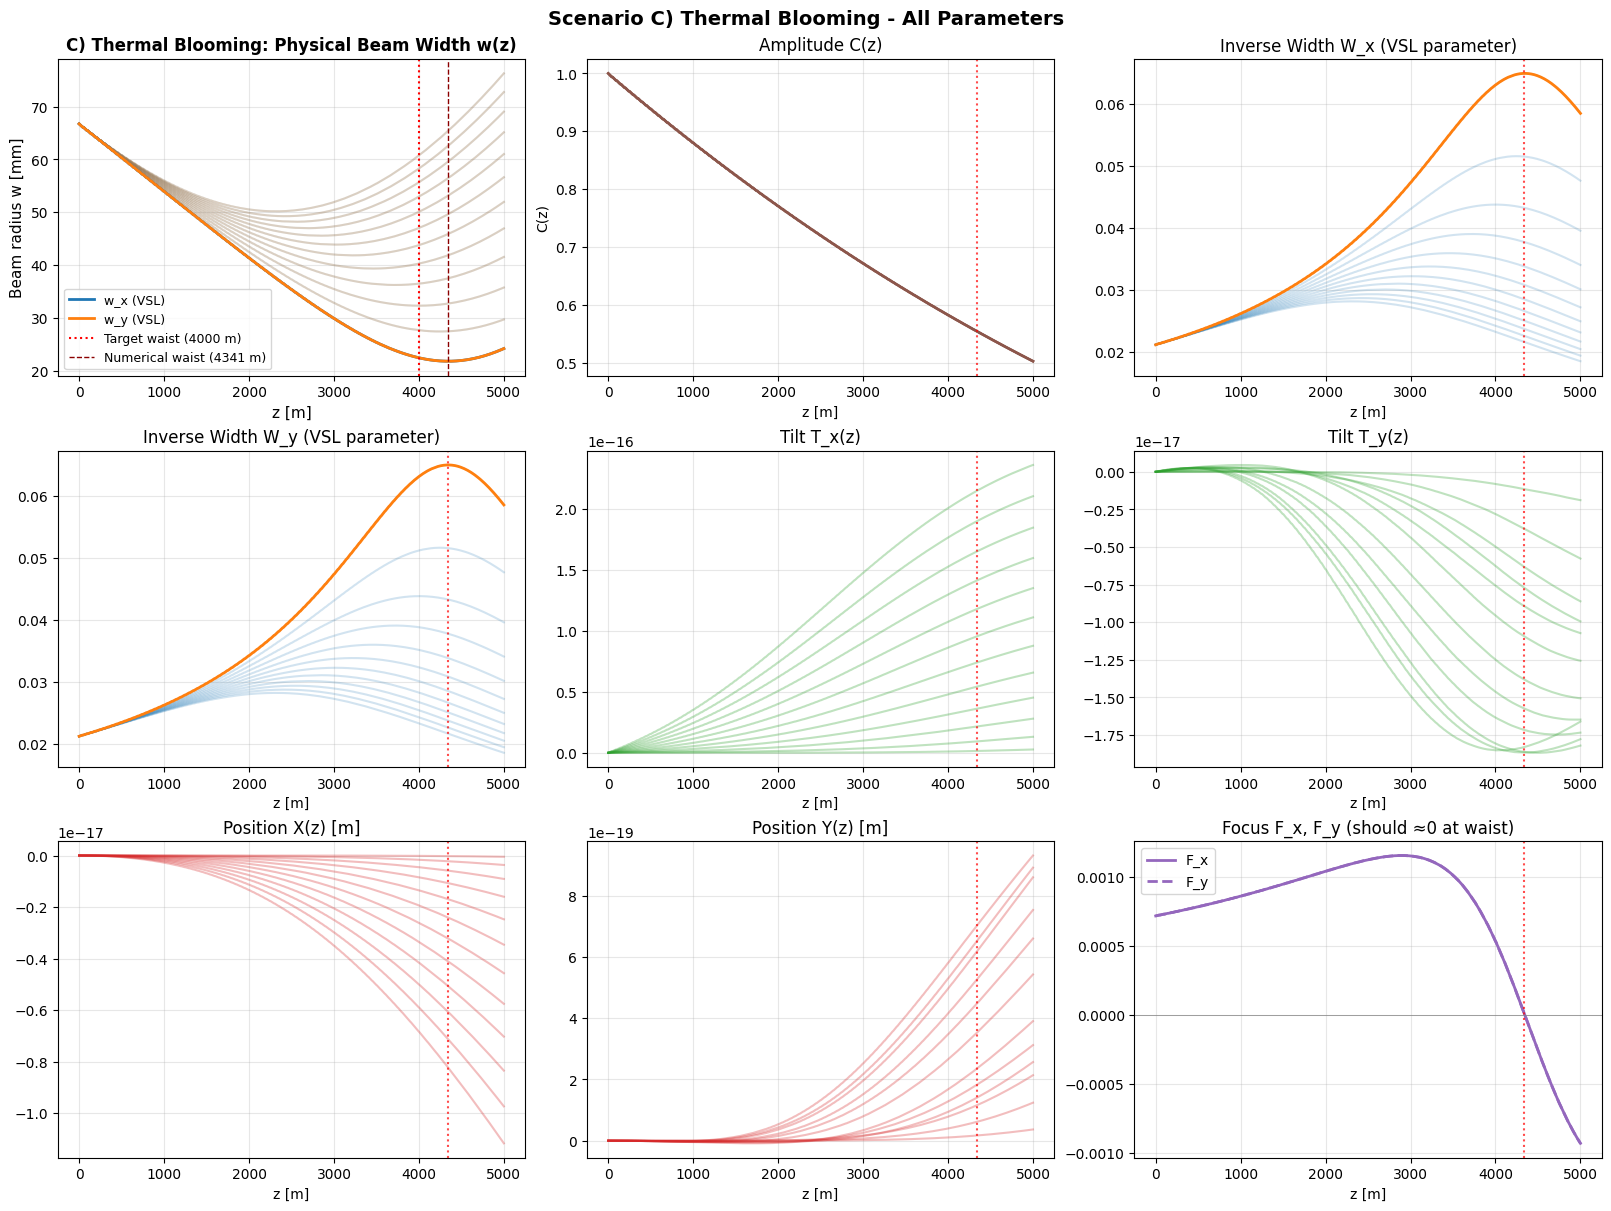

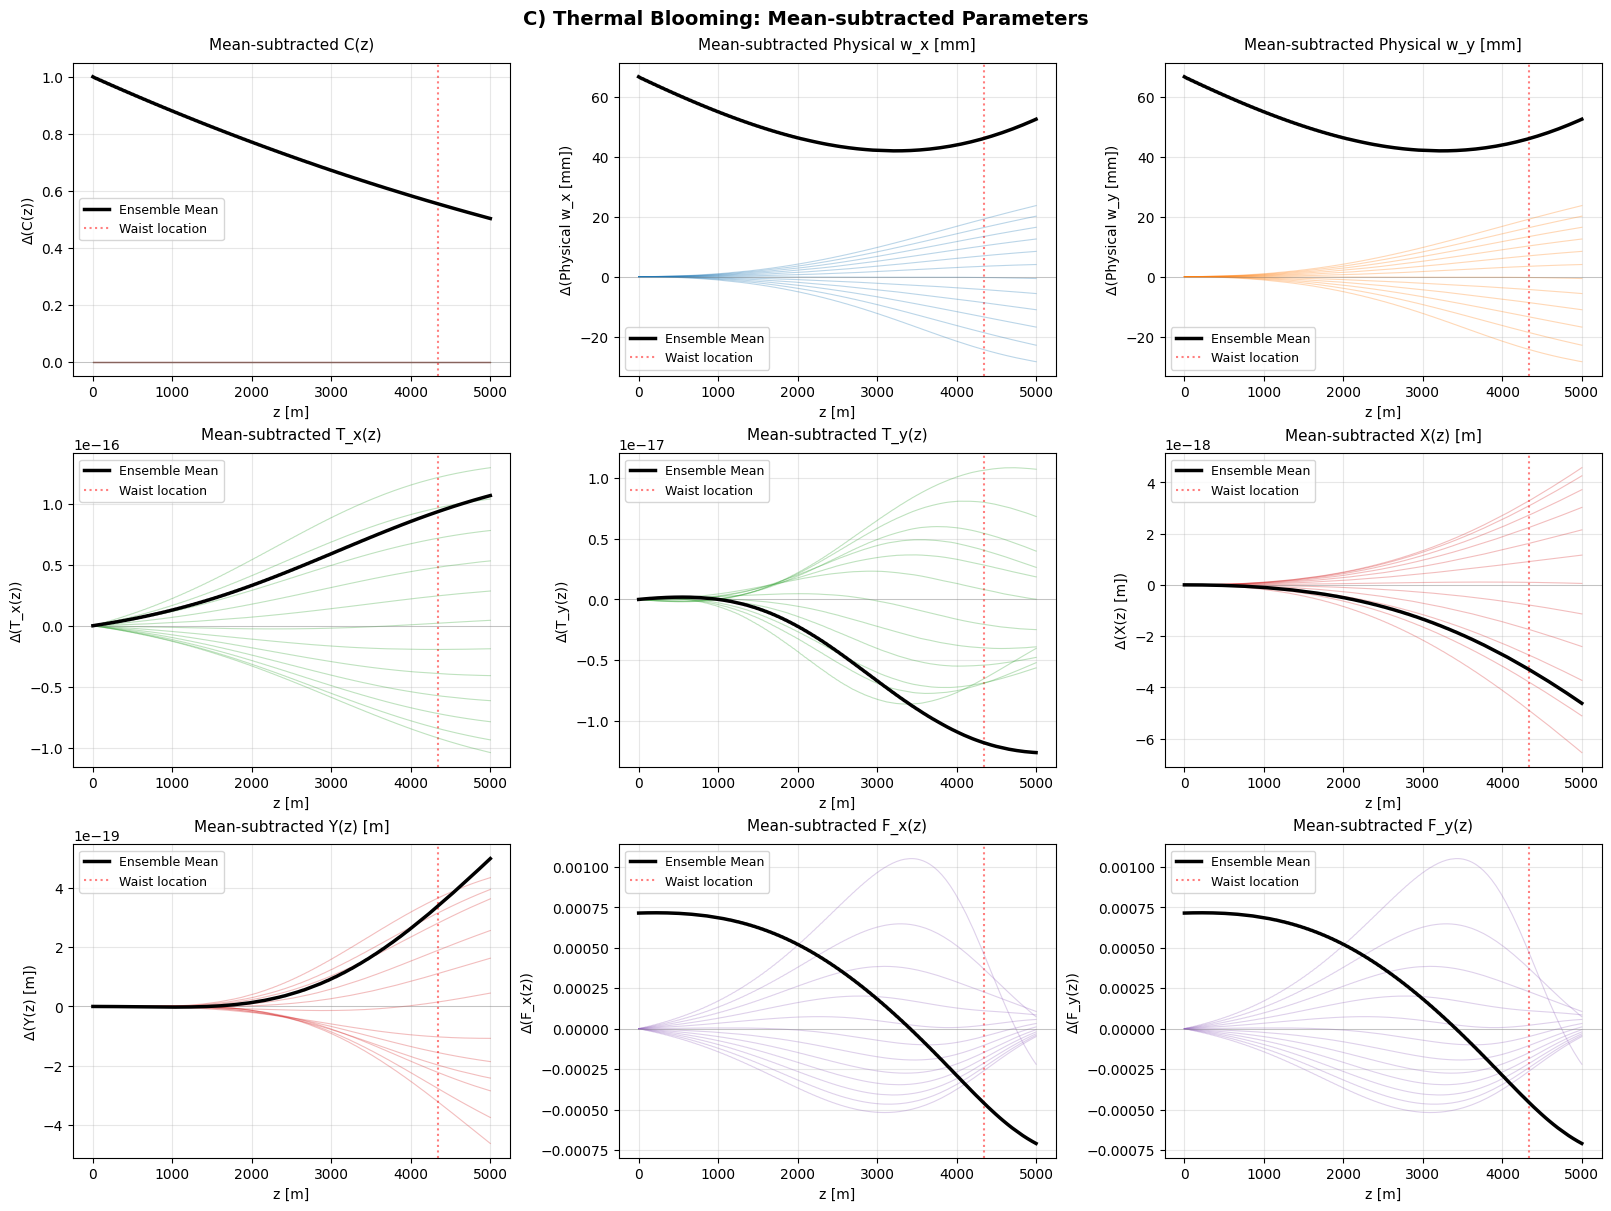


Scenario D) Turbulence + Thermal
Target waist: 20.0 mm at z = 4000 m

Numerical Results:
  Waist location (X): 4349 m
  Waist location (Y): 4349 m
  Waist width (X):    21.38 mm
  Waist width (Y):    21.38 mm
  F_x at waist:       +2.916e-06
  F_y at waist:       +2.916e-06

End state statistics (z = 5000 m):
  Tilt Tx: -1.03e-09 ± 1.60e-09
  Tilt Ty: +3.41e-10 ± 1.54e-09
  Position X: +3.14e-11 ± 8.49e-11 m
  Position Y: -3.76e-11 ± 7.64e-11 m


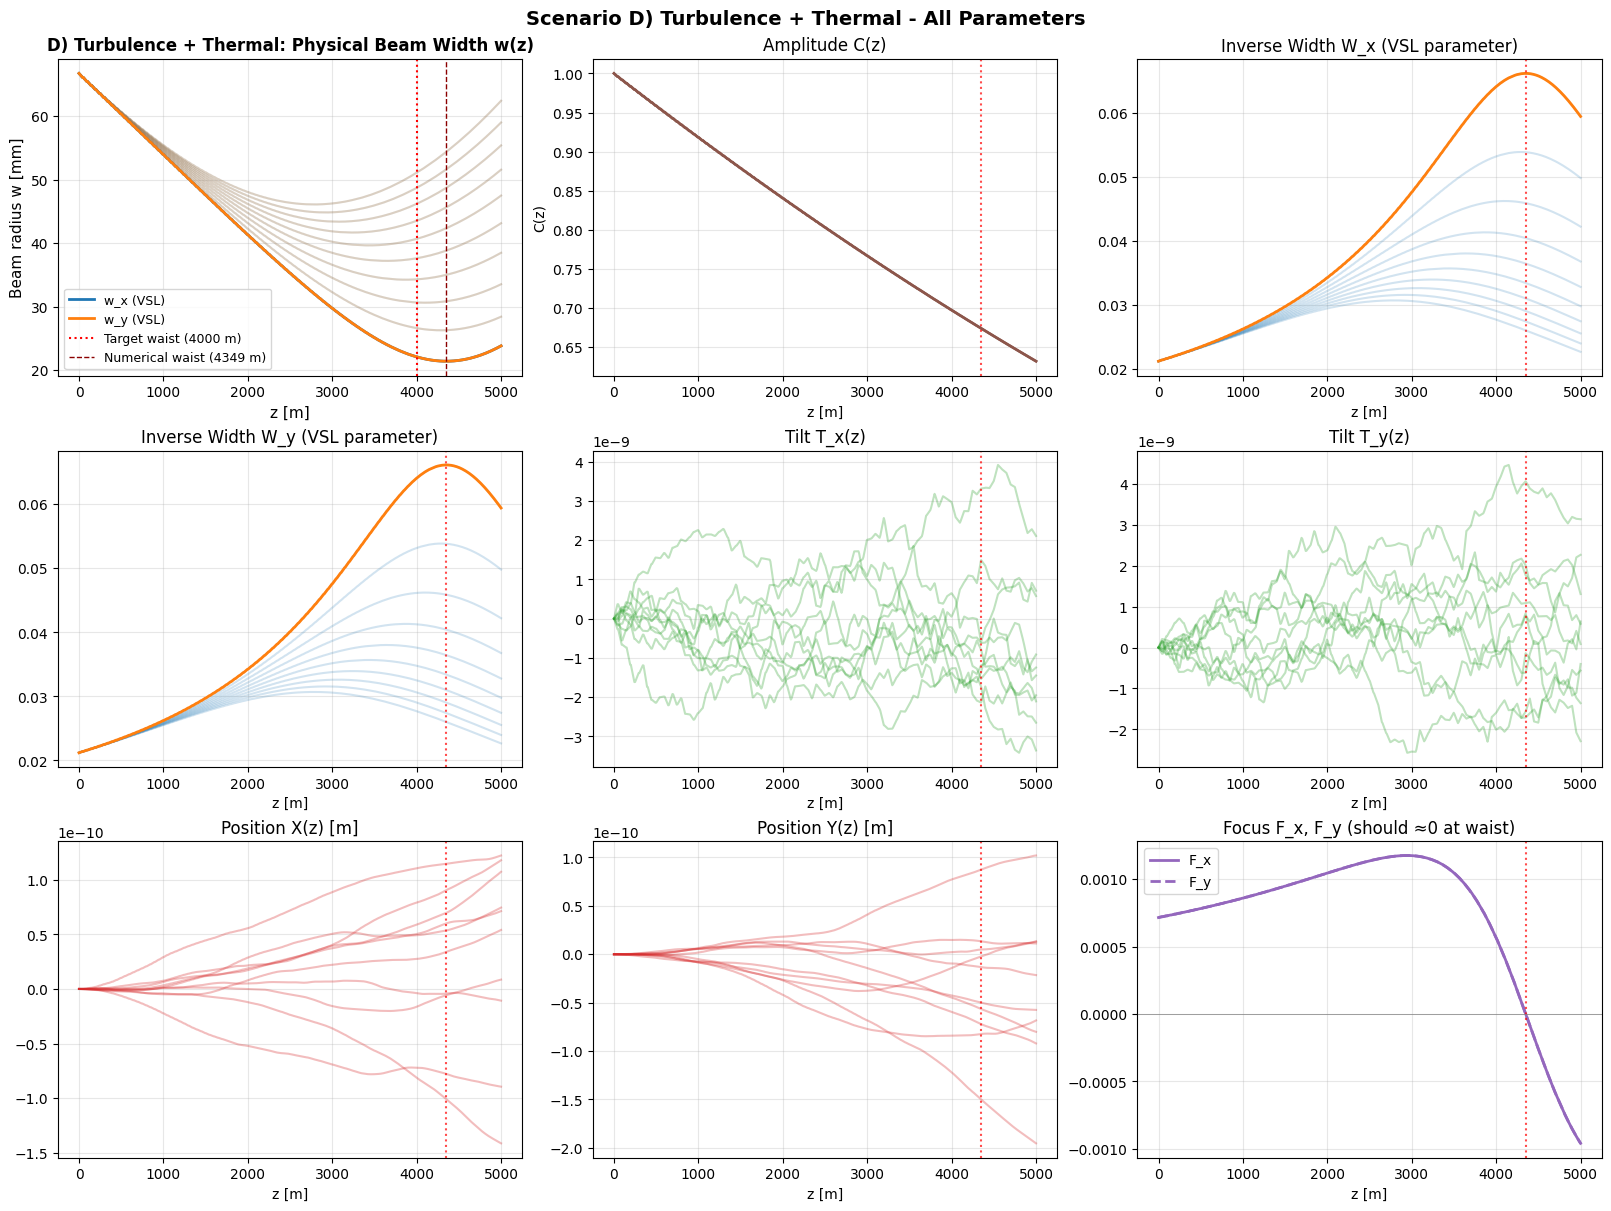

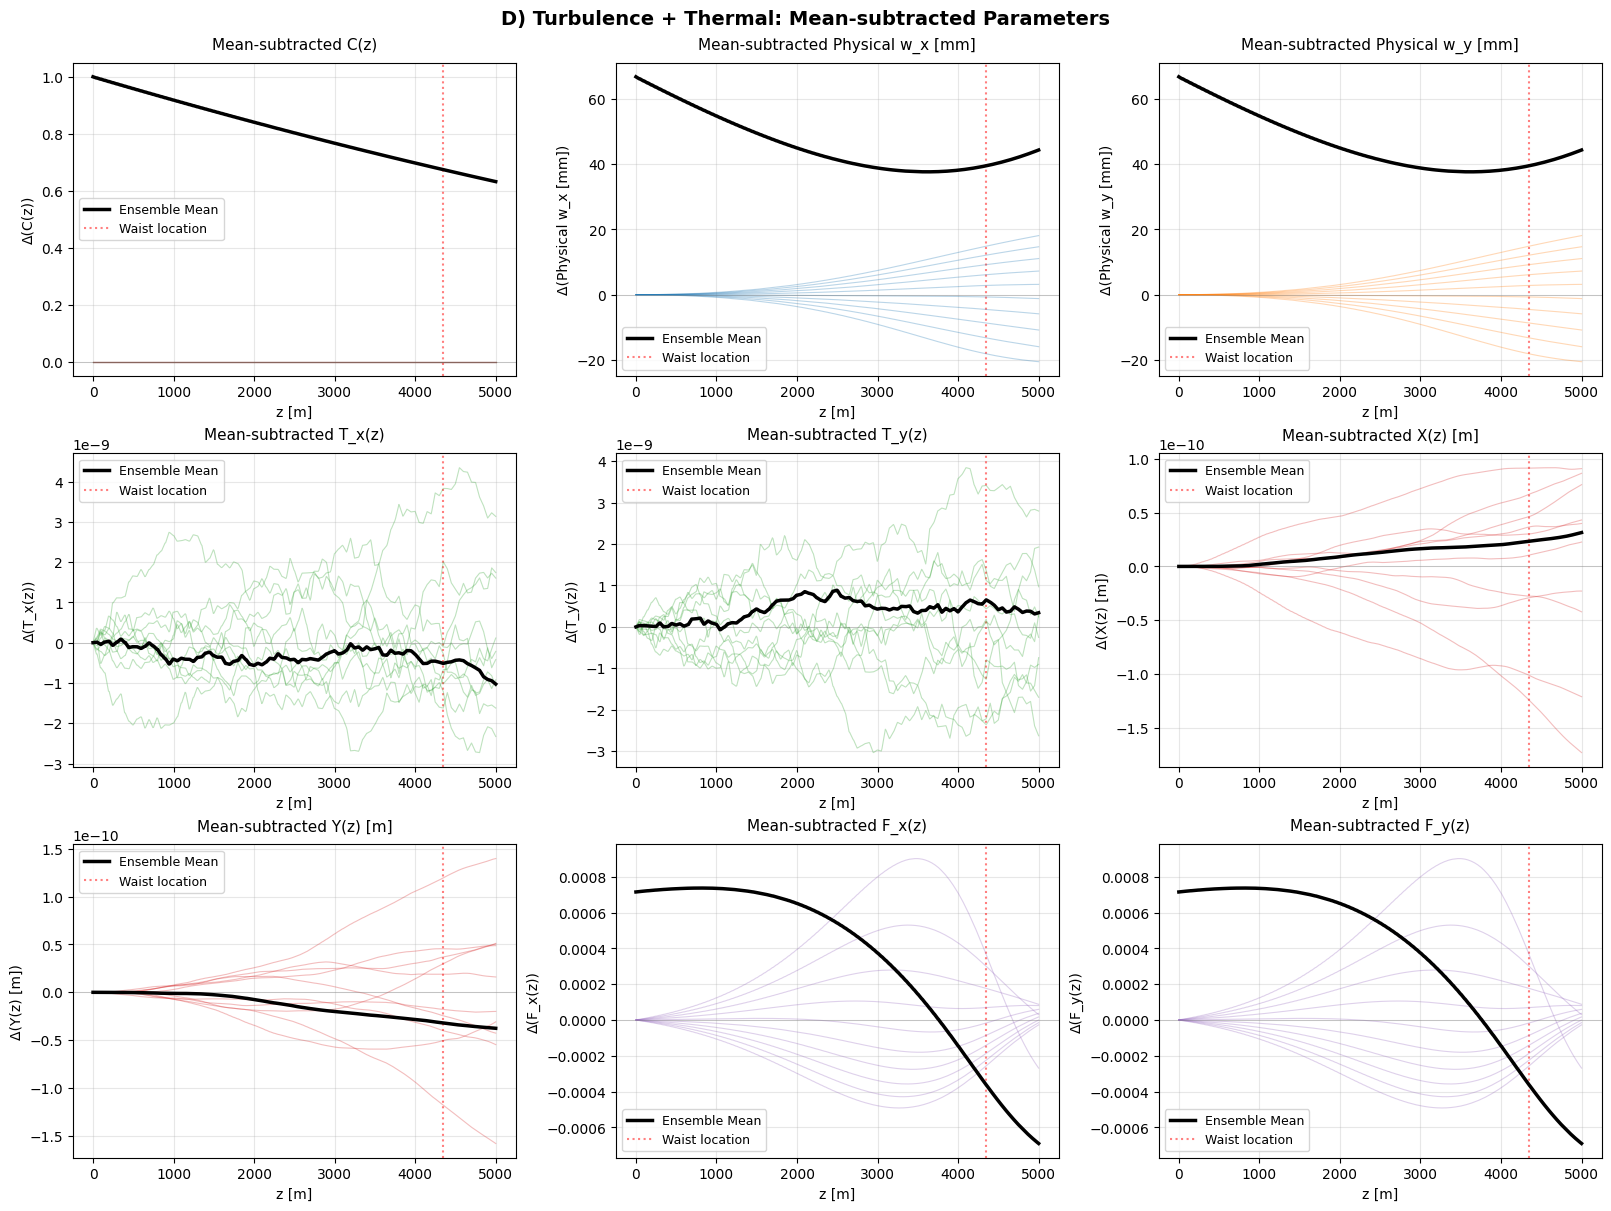

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.fft import fft2, ifft2, fftfreq

class AtmosphericParameters:
    def __init__(
        self,
        wavelength=1e-6,
        Cn2=5e-18,
        propagation_distance=5000.0,
        l0=1e-3,
        L0=100.0,
        alpha_loss_per_m=0.0,
        dn_dT_phys=-9.4e-7,
        temp_scale_K=1.0,
    ):
        self.wavelength = wavelength
        self.k0 = 2.0 * np.pi / wavelength
        self.Cn2 = Cn2
        self.L_physical = propagation_distance
        self.l0 = l0
        self.L0 = L0
        self.n = 1.000277
        self.alpha_loss_per_m = alpha_loss_per_m
        self.alpha_nd = self.alpha_loss_per_m * self.L0
        self.dn_dT_phys = dn_dT_phys
        self.temp_scale_K = temp_scale_K
        self.xi = (self.l0**2 * self.k0) / self.L0
        self.sigma = 0.5 * self.Cn2 * (self.L0 ** (2.0 / 3.0))
        self.gamma = self.l0 * self.k0 * np.sqrt(self.sigma)
        self.L = self.L_physical / self.L0

def generate_delta_n_kolmogorov(N, delta_nd, params, scale=1.0):
    fx = fftfreq(N, d=delta_nd)
    fy = fftfreq(N, d=delta_nd)
    fx, fy = np.meshgrid(fx, fy)
    f = np.sqrt(fx**2 + fy**2)
    f[f == 0] = 1e-12

    kappa_nd = 2.0 * np.pi * f
    kappa_0_nd = 2.0 * np.pi / (params.L0 / params.l0)
    kappa_m_nd = 5.92

    Phi_shape = np.exp(-(kappa_nd / kappa_m_nd) ** 2) / (
        (kappa_nd**2 + kappa_0_nd**2) ** (11.0 / 6.0)
    )

    rnd = (np.random.randn(N, N) + 1j * np.random.randn(N, N)) * np.sqrt(Phi_shape)
    field = np.real(ifft2(rnd))
    field -= np.mean(field)
    std = np.std(field)
    if std > 0:
        field /= std
    return scale * field

def solve_heat_step(
    Xc, Yc, W_x, W_y, alpha_nd, rho_nd, cp_nd, C, kappa_nd,
    X_grid, Y_grid, T_prev_nd, dx, dy, dz,
):
    xprime = X_grid - Xc
    yprime = Y_grid - Yc
    exponent = -(W_x**2 * xprime**2 + W_y**2 * yprime**2)
    I_nd = (C**2 * W_x * W_y / np.pi) * np.exp(exponent)

    source = alpha_nd * I_nd / max(rho_nd * cp_nd, 1e-12)

    kx = 2.0 * np.pi * fftfreq(X_grid.shape[1], d=dx)
    ky = 2.0 * np.pi * fftfreq(X_grid.shape[0], d=dy)
    kx, ky = np.meshgrid(kx, ky)
    k2 = kx**2 + ky**2

    T_fft = fft2(T_prev_nd)
    T_diff_fft = np.exp(-kappa_nd * k2 * dz) * T_fft
    T_diff = np.real(ifft2(T_diff_fft))
    return T_diff + source * dz

def beam_system(z_prop, y, dn_th_nd, dn_turb_nd, X_grid, Y_grid, params):
    """
    VSL ODEs - NOTE: z_prop required by solve_ivp but not used in equations
    (equations are already in z-derivative form)
    """
    C, W_x, W_y, T_x, T_y, Xc, Yc, F_x, F_y, P = y

    W_x = np.clip(W_x, 1e-5, 1e5)
    W_y = np.clip(W_y, 1e-5, 1e5)

    n = params.n
    xi = params.xi
    gamma = params.gamma

    dn_total = dn_turb_nd + dn_th_nd

    xprime = X_grid - Xc
    yprime = Y_grid - Yc
    exp_term = np.exp(-(W_x**2 * xprime**2 + W_y**2 * yprime**2))
    base = (W_x * W_y / np.pi) * exp_term

    M_Tx = 4.0 * (W_x**2) * xprime * base
    M_Ty = 4.0 * (W_y**2) * yprime * base
    M_Fx = (W_x**2) * (1.0 - 2.0 * (W_x**2) * xprime**2) * base
    M_Fy = (W_y**2) * (1.0 - 2.0 * (W_y**2) * yprime**2) * base
    M_P = (2.0 - (W_x**2) * xprime**2 - (W_y**2) * yprime**2) * base

    dx = X_grid[0, 1] - X_grid[0, 0]
    dy = Y_grid[1, 0] - Y_grid[0, 0]

    int_Tx = np.sum(dn_total * M_Tx) * dx * dy
    int_Ty = np.sum(dn_total * M_Ty) * dx * dy
    int_Fx = np.sum(dn_total * M_Fx) * dx * dy
    int_Fy = np.sum(dn_total * M_Fy) * dx * dy
    int_P = np.sum(dn_total * M_P) * dx * dy

    dC_dz = -(params.alpha_nd / 2.0) * C
    dW_x_dz = (2.0 / (n * xi)) * F_x * W_x
    dW_y_dz = (2.0 / (n * xi)) * F_y * W_y
    dT_x_dz = -n * (gamma**2) * int_Tx
    dT_y_dz = -n * (gamma**2) * int_Ty
    dX_dz = -2.0 * T_x
    dY_dz = -2.0 * T_y
    dF_x_dz = (-(W_x**4) / (2.0 * n * xi)) + (2.0 * (F_x**2) / (n * xi)) + (
        (gamma**2) / xi
    ) * int_Fx
    dF_y_dz = (-(W_y**4) / (2.0 * n * xi)) + (2.0 * (F_y**2) / (n * xi)) + (
        (gamma**2) / xi
    ) * int_Fy
    dP_dz = ((W_x**2 + W_y**2) / (2.0 * n * xi)) - ((gamma**2) / xi) * int_P

    return [
        dC_dz, dW_x_dz, dW_y_dz, dT_x_dz, dT_y_dz,
        dX_dz, dY_dz, dF_x_dz, dF_y_dz, dP_dz,
    ]

def gaussian_initials_for_target_waist(params, waist_at_focus_m, z_focus_m):
    w0 = waist_at_focus_m
    z_waist = z_focus_m  # Renamed for clarity
    z_R = np.pi * w0**2 / params.wavelength

    w_init = w0 * np.sqrt(1.0 + (z_waist / z_R) ** 2)
    dw_dz_phys = -w0 * z_waist / (z_R**2 * np.sqrt(1.0 + (z_waist / z_R) ** 2))

    W0 = (np.sqrt(2.0) * params.l0) / max(w_init, 1e-12)
    dW_dz_phys = -np.sqrt(2.0) * params.l0 * dw_dz_phys / (w_init**2 + 1e-30)
    dW_dz_nd = params.L0 * dW_dz_phys
    F0 = (params.n * params.xi / (2.0 * W0)) * dW_dz_nd

    return W0, F0

def compute_exact_gaussian_width(z_phys, params, waist_at_focus_m, z_focus_m):
    w0 = waist_at_focus_m
    z_waist = z_focus_m  # Renamed for clarity
    z_R = np.pi * w0**2 / params.wavelength

    w_exact = w0 * np.sqrt(1.0 + ((z_phys - z_waist) / z_R) ** 2)
    return w_exact

def run_scenario(
    label, use_turbulence, use_thermal, turbulence_scale,
    alpha_loss_per_m, kappa_nd, num_pulses,
    reset_temperature_each_pulse, seed,
    z_focus_m, waist_at_focus_m,
):
    np.random.seed(seed)
    params = AtmosphericParameters(
        wavelength=1e-6,
        Cn2=5e-18,
        propagation_distance=5000.0,
        l0=1e-3,
        L0=100.0,
        alpha_loss_per_m=alpha_loss_per_m,
        dn_dT_phys=-9.4e-7,
        temp_scale_K=1.0,
    )

    W0, F0 = gaussian_initials_for_target_waist(params, waist_at_focus_m, z_focus_m)
    y0 = np.array([1.0, W0, W0, 0.0, 0.0, 0.0, 0.0, F0, F0, 0.0], dtype=float)

    w_init_phys = np.sqrt(2.0) * params.l0 / W0
    w_init_nd = w_init_phys / params.l0
    L_trans = max(10.0 * w_init_nd, 80.0)
    N = 128
    X_nd = np.linspace(-L_trans / 2, L_trans / 2, N)
    Y_nd = np.linspace(-L_trans / 2, L_trans / 2, N)
    X_grid, Y_grid = np.meshgrid(X_nd, Y_nd)
    dx = X_nd[1] - X_nd[0]
    # Removed unused X_phys, Y_phys

    segment_length = 0.5
    num_segments = int(np.ceil(params.L / segment_length))
    points_per_segment = 6
    num_z = num_segments * points_per_segment
    z_phys = np.linspace(0, params.L_physical, num_z)
    z_nd_global = z_phys / params.L0

    all_pulse_y = []
    T_nd = np.zeros((N, N))

    for p in range(num_pulses):
        state = y0.copy()
        pulse_y = []

        z_current = 0.0  # Renamed from z_cur for clarity
        for s in range(num_segments):
            # Renamed z0 -> z_seg_start, z1 -> z_seg_end for clarity
            z_seg_start = z_current
            z_seg_end = min(z_seg_start + segment_length, params.L)

            mask = (z_nd_global >= z_seg_start) & (z_nd_global <= z_seg_end)
            z_eval = z_nd_global[mask]

            if len(z_eval) < 2:
                z_eval = np.linspace(z_seg_start, z_seg_end, points_per_segment)

            dz_step = z_eval[1] - z_eval[0] if len(z_eval) > 1 else 0.0
            z_current = z_seg_end

            dn_turb = (
                generate_delta_n_kolmogorov(N, dx, params, turbulence_scale)
                if use_turbulence
                else np.zeros_like(T_nd)
            )

            if use_thermal:
                W_x = max(state[1], 1e-12)
                W_y = max(state[2], 1e-12)
                Xc, Yc, C = state[5], state[6], state[0]
                T_nd = solve_heat_step(
                    Xc, Yc, W_x, W_y, params.alpha_nd,
                    rho_nd=1.0, cp_nd=1.0, C=C, kappa_nd=kappa_nd,
                    X_grid=X_grid, Y_grid=Y_grid, T_prev_nd=T_nd,
                    dx=dx, dy=dx, dz=dz_step,
                )
                dT_phys = params.temp_scale_K * T_nd
                dn_th_phys = params.dn_dT_phys * dT_phys
                dn_th_nd = dn_th_phys / max(params.sigma, 1e-20)
            else:
                dn_th_nd = np.zeros_like(T_nd)

            def rhs(z_prop, y):
                return beam_system(z_prop, y, dn_th_nd, dn_turb, X_grid, Y_grid, params)

            sol = solve_ivp(
                rhs,
                [z_seg_start, z_seg_end],
                state,
                t_eval=z_eval,
                method="RK45",
                rtol=5e-4,
                atol=1e-6,
                max_step=0.2,
            )
            if sol.success:
                state = sol.y[:, -1]
                pulse_y.append(sol.y)
            else:
                tiled_y = np.tile(state[:, None], (1, len(z_eval)))
                pulse_y.append(tiled_y)

        all_pulse_y.append(np.hstack(pulse_y))

        if reset_temperature_each_pulse:
            T_nd.fill(0.0)

    y = all_pulse_y[0]
    w_x_phys = (np.sqrt(2.0) * params.l0) / np.maximum(y[1], 1e-12)
    w_y_phys = (np.sqrt(2.0) * params.l0) / np.maximum(y[2], 1e-12)

    iwaist_x = np.argmax(y[1])
    iwaist_y = np.argmax(y[2])
    z_waist_x = z_phys[iwaist_x]
    z_waist_y = z_phys[iwaist_y]

    w_exact_x = compute_exact_gaussian_width(z_phys, params, waist_at_focus_m, z_focus_m)
    w_exact_y = w_exact_x.copy()

    F_at_waist_x = y[7, iwaist_x]
    F_at_waist_y = y[8, iwaist_y]
    w_at_waist_x = w_x_phys[iwaist_x]
    w_at_waist_y = w_y_phys[iwaist_y]

    TX_end = np.array([yy[3, -1] for yy in all_pulse_y])
    TY_end = np.array([yy[4, -1] for yy in all_pulse_y])
    X_end = np.array([yy[5, -1] for yy in all_pulse_y]) * params.l0
    Y_end = np.array([yy[6, -1] for yy in all_pulse_y]) * params.l0

    print(f"\n{'='*60}")
    print(f"Scenario {label}")
    print(f"{'='*60}")
    print(f"Target waist: {waist_at_focus_m*1e3:.1f} mm at z = {z_focus_m:.0f} m")
    print(f"\nNumerical Results:")
    print(f"  Waist location (X): {z_waist_x:.0f} m")
    print(f"  Waist location (Y): {z_waist_y:.0f} m")
    print(f"  Waist width (X):    {w_at_waist_x*1e3:.2f} mm")
    print(f"  Waist width (Y):    {w_at_waist_y*1e3:.2f} mm")
    print(f"  F_x at waist:       {F_at_waist_x:+.3e}")
    print(f"  F_y at waist:       {F_at_waist_y:+.3e}")

    if not use_turbulence and not use_thermal:
        rel_error_loc = abs(z_waist_x - z_focus_m) / z_focus_m * 100
        rel_error_w = abs(w_at_waist_x - waist_at_focus_m) / waist_at_focus_m * 100
        w_rms_error = np.sqrt(np.mean((w_x_phys - w_exact_x)**2)) * 1e3
        print(f"\nVacuum Verification:")
        print(f"  Waist location error: {rel_error_loc:.2f}%")
        print(f"  Waist width error:    {rel_error_w:.2f}%")
        print(f"  RMS width error:      {w_rms_error:.3f} mm")

    print(f"\nEnd state statistics (z = {params.L_physical:.0f} m):")
    print(f"  Tilt Tx: {TX_end.mean():+.2e} ± {TX_end.std():.2e}")
    print(f"  Tilt Ty: {TY_end.mean():+.2e} ± {TY_end.std():.2e}")
    print(f"  Position X: {X_end.mean():+.2e} ± {X_end.std():.2e} m")
    print(f"  Position Y: {Y_end.mean():+.2e} ± {Y_end.std():.2e} m")

    if num_pulses > 1:
        mean_C = np.zeros(num_z)
        mean_Wx = np.zeros(num_z)
        mean_Wy = np.zeros(num_z)
        mean_Tx = np.zeros(num_z)
        mean_Ty = np.zeros(num_z)
        mean_X = np.zeros(num_z)
        mean_Y = np.zeros(num_z)
        mean_Fx = np.zeros(num_z)
        mean_Fy = np.zeros(num_z)
        mean_wx = np.zeros(num_z)
        mean_wy = np.zeros(num_z)

        for yy in all_pulse_y:
            mean_C += yy[0]
            mean_Wx += yy[1]
            mean_Wy += yy[2]
            mean_Tx += yy[3]
            mean_Ty += yy[4]
            mean_X += yy[5] * params.l0
            mean_Y += yy[6] * params.l0
            mean_Fx += yy[7]
            mean_Fy += yy[8]
            mean_wx += (np.sqrt(2.0) * params.l0) / np.maximum(yy[1], 1e-12)
            mean_wy += (np.sqrt(2.0) * params.l0) / np.maximum(yy[2], 1e-12)

        mean_C /= num_pulses
        mean_Wx /= num_pulses
        mean_Wy /= num_pulses
        mean_Tx /= num_pulses
        mean_Ty /= num_pulses
        mean_X /= num_pulses
        mean_Y /= num_pulses
        mean_Fx /= num_pulses
        mean_Fy /= num_pulses
        mean_wx /= num_pulses
        mean_wy /= num_pulses

    fig, axes = plt.subplots(3, 3, figsize=(16, 12), constrained_layout=True)
    axes = axes.flatten()

    for yy in all_pulse_y:
        w_x_pulse = (np.sqrt(2.0) * params.l0) / np.maximum(yy[1], 1e-12)
        w_y_pulse = (np.sqrt(2.0) * params.l0) / np.maximum(yy[2], 1e-12)
        axes[0].plot(z_phys, w_x_pulse * 1e3, 'C0', alpha=0.2)
        axes[0].plot(z_phys, w_y_pulse * 1e3, 'C1', alpha=0.2)

    axes[0].plot(z_phys, w_x_phys * 1e3, 'C0', linewidth=2, label='w_x (VSL)')
    axes[0].plot(z_phys, w_y_phys * 1e3, 'C1', linewidth=2, label='w_y (VSL)')

    if not use_turbulence and not use_thermal:
        axes[0].plot(z_phys, w_exact_x * 1e3, 'k--', linewidth=2,
                    label='Exact: w₀√[1+(z-z₀)²/z_R²]')

    axes[0].axvline(z_focus_m, color='red', linestyle=':', linewidth=1.5,
                   label=f'Target waist ({z_focus_m:.0f} m)')
    axes[0].axvline(z_waist_x, color='darkred', linestyle='--', linewidth=1,
                   label=f'Numerical waist ({z_waist_x:.0f} m)')

    axes[0].set_xlabel('z [m]', fontsize=11)
    axes[0].set_ylabel('Beam radius w [mm]', fontsize=11)
    axes[0].set_title(f'{label}: Physical Beam Width w(z)', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=9, loc='best')
    axes[0].grid(True, alpha=0.3)

    for yy in all_pulse_y:
        axes[1].plot(z_phys, yy[0], 'C5', alpha=0.2)
    axes[1].plot(z_phys, y[0], 'C5', linewidth=2)
    axes[1].axvline(z_waist_x, color='red', linestyle=':', alpha=0.7)
    axes[1].set_xlabel('z [m]')
    axes[1].set_ylabel('C(z)')
    axes[1].set_title('Amplitude C(z)')
    axes[1].grid(True, alpha=0.3)

    for yy in all_pulse_y:
        axes[2].plot(z_phys, yy[1], 'C0', alpha=0.2)
        axes[3].plot(z_phys, yy[2], 'C0', alpha=0.2)
    axes[2].plot(z_phys, y[1], 'C1', linewidth=2)
    axes[3].plot(z_phys, y[2], 'C1', linewidth=2)
    axes[2].axvline(z_waist_x, color='red', linestyle=':', alpha=0.7)
    axes[3].axvline(z_waist_x, color='red', linestyle=':', alpha=0.7)
    axes[2].set_title('Inverse Width W_x (VSL parameter)')
    axes[3].set_title('Inverse Width W_y (VSL parameter)')
    for ax in [axes[2], axes[3]]:
        ax.set_xlabel('z [m]')
        ax.grid(True, alpha=0.3)

    for yy in all_pulse_y:
        axes[4].plot(z_phys, yy[3], 'C2', alpha=0.3)
        axes[5].plot(z_phys, yy[4], 'C2', alpha=0.3)
    axes[4].axvline(z_waist_x, color='red', linestyle=':', alpha=0.7)
    axes[5].axvline(z_waist_x, color='red', linestyle=':', alpha=0.7)
    axes[4].set_title('Tilt T_x(z)')
    axes[5].set_title('Tilt T_y(z)')
    for ax in [axes[4], axes[5]]:
        ax.set_xlabel('z [m]')
        ax.grid(True, alpha=0.3)

    for yy in all_pulse_y:
        axes[6].plot(z_phys, yy[5] * params.l0, 'C3', alpha=0.3)
        axes[7].plot(z_phys, yy[6] * params.l0, 'C3', alpha=0.3)
    axes[6].axvline(z_waist_x, color='red', linestyle=':', alpha=0.7)
    axes[7].axvline(z_waist_x, color='red', linestyle=':', alpha=0.7)
    axes[6].set_title('Position X(z) [m]')
    axes[7].set_title('Position Y(z) [m]')
    for ax in [axes[6], axes[7]]:
        ax.set_xlabel('z [m]')
        ax.grid(True, alpha=0.3)

    axes[8].plot(z_phys, y[7], 'C4', linewidth=2, label='F_x')
    axes[8].plot(z_phys, y[8], 'C4--', linewidth=2, label='F_y')
    axes[8].axvline(z_waist_x, color='red', linestyle=':', alpha=0.7)
    axes[8].axhline(0, color='gray', linestyle='-', linewidth=0.5)
    axes[8].set_title('Focus F_x, F_y (should ≈0 at waist)')
    axes[8].set_xlabel('z [m]')
    axes[8].legend()
    axes[8].grid(True, alpha=0.3)

    fig.suptitle(f'Scenario {label} - All Parameters', fontsize=14, fontweight='bold')

    if num_pulses > 1:
        fig_corr, axes_corr = plt.subplots(3, 3, figsize=(16, 12), constrained_layout=True)
        axes_corr = axes_corr.flatten()

        plot_configs = [
            ("C(z)", mean_C, "C5", 0, False, False),
            ("Physical w_x [mm]", mean_wx * 1e3, "C0", 1, True, False),
            ("Physical w_y [mm]", mean_wy * 1e3, "C1", 2, True, False),
            ("T_x(z)", mean_Tx, "C2", 3, False, False),
            ("T_y(z)", mean_Ty, "C2", 4, False, False),
            ("X(z) [m]", mean_X, "C3", 5, False, True),
            ("Y(z) [m]", mean_Y, "C3", 6, False, True),
            ("F_x(z)", mean_Fx, "C4", 7, False, False),
            ("F_y(z)", mean_Fy, "C4", 8, False, False),
        ]

        for ax_idx, (param_name, mean_array, color, y_idx, is_phys_width, is_pos) in enumerate(plot_configs):
            ax = axes_corr[ax_idx]

            ax.plot(z_phys, mean_array, color="black", linewidth=2.5, label="Ensemble Mean", zorder=10)
            ax.axvline(z_waist_x, color='red', linestyle=':', alpha=0.5, linewidth=1.5, label='Waist location')

            for yy in all_pulse_y:
                if is_phys_width:
                    values = ((np.sqrt(2.0) * params.l0) / np.maximum(yy[y_idx], 1e-12)) * 1e3
                elif is_pos:
                    values = yy[y_idx] * params.l0
                else:
                    values = yy[y_idx]

                subtracted = values - mean_array
                ax.plot(z_phys, subtracted, color=color, alpha=0.3, linewidth=0.8)

            ax.set_title(f"Mean-subtracted {param_name}", pad=10, fontsize=11)
            ax.grid(True, alpha=0.3)
            ax.set_xlabel("z [m]", fontsize=10)
            ax.set_ylabel(f"Δ({param_name})", fontsize=10)
            ax.legend(fontsize=9, loc='best')
            ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

        fig_corr.suptitle(f"{label}: Mean-subtracted Parameters",
                         fontsize=14, fontweight='bold')

    plt.show()

if __name__ == "__main__":
    z_focus_m = 4000.0
    waist_at_focus_m = 0.02

    print("\n" + "="*60)
    print("GAUSSIAN BEAM PROPAGATION: VSL vs. Exact Formula")
    print("="*60)
    print(f"\nTheory: Exact vacuum Gaussian beam formula")
    print(f"  w(z) = w₀ √[1 + ((z-z₀)/z_R)²]")
    print(f"  where z_R = π w₀²/λ (Rayleigh range)")
    print(f"\nSource: Siegman, 'Lasers' (1986), Ch. 17")

    run_scenario(
        label="A) Vacuum (Exact Comparison)",
        use_turbulence=False,
        use_thermal=False,
        turbulence_scale=0.0,
        alpha_loss_per_m=0.0,
        kappa_nd=0.0,
        num_pulses=1,
        reset_temperature_each_pulse=True,
        seed=1,
        z_focus_m=z_focus_m,
        waist_at_focus_m=waist_at_focus_m,
    )

    run_scenario(
        label="B) Atmospheric Turbulence",
        use_turbulence=True,
        use_thermal=False,
        turbulence_scale=15.0,
        alpha_loss_per_m=0.0,
        kappa_nd=0.0,
        num_pulses=10,
        reset_temperature_each_pulse=True,
        seed=2,
        z_focus_m=z_focus_m,
        waist_at_focus_m=waist_at_focus_m,
    )

    run_scenario(
        label="C) Thermal Blooming",
        use_turbulence=False,
        use_thermal=True,
        turbulence_scale=0.0,
        alpha_loss_per_m=3e-4,
        kappa_nd=2e-3,
        num_pulses=12,
        reset_temperature_each_pulse=False,
        seed=3,
        z_focus_m=z_focus_m,
        waist_at_focus_m=waist_at_focus_m,
    )

    run_scenario(
        label="D) Turbulence + Thermal",
        use_turbulence=True,
        use_thermal=True,
        turbulence_scale=12.0,
        alpha_loss_per_m=2e-4,
        kappa_nd=2e-3,
        num_pulses=10,
        reset_temperature_each_pulse=False,
        seed=4,
        z_focus_m=z_focus_m,
        waist_at_focus_m=waist_at_focus_m,
    )